# Cyberbullying Tweet Multiclass Classifier

**Course:** WQF7007 Natural Language Processing | University of Malaya, Master of Data Science  
**Approach:** TF-IDF Baselines + Fine-Tuned DistilBERT (HuggingFace)  
**Dataset:** Cyberbullying Tweets — 6 classes, ~47,692 samples  

---

## Pipeline Overview

```
cyberbullying_tweets.csv
         │
         ▼
[0] Environment Setup & Drive Mount
         │
         ▼
[1] Load & Explore Data (EDA)
         │
         ▼
[2] Preprocessing & Train/Val/Test Split
         │
         ▼
[3] Baseline — TF-IDF + Logistic Regression & SVM
         │
         ▼
[4] Main Model — Fine-Tuned DistilBERT
         │
         ▼
[5] Evaluation & Comparison
```

---
## Section 0 — Environment Setup

In [1]:
# Install required packages (safe to re-run — skips already installed)
!pip install -q transformers datasets accelerate
!pip install -q scikit-learn pandas numpy torch

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# ── GPU check ──────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found — training will be very slow on CPU.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
# # Mount Google Drive (Colab) — skip if running locally
# try:
#     from google.colab import drive
#     drive.mount('/content/drive', force_remount=True)
#     ON_COLAB = True
# except ImportError:
#     ON_COLAB = False
#     print("Not on Colab — using local paths.")

# print(f"Running on Colab: {ON_COLAB}")

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

In [3]:
# ── Path & Model Configuration ─────────────────────────────────────────────
# if ON_COLAB:
#     DATASET_PATH = '/content/drive/MyDrive/1_UM/1_NLP Project/dataset/cyberbullying_tweets.csv'
#     OUTPUT_DIR   = '/content/drive/MyDrive/1_UM/1_NLP Project/distilbert-cyberbullying'
# else:
#     DATASET_PATH = '/kaggle/input/datasets/faizyah/cyberbulling-tweet/cyberbullying_tweets.csv'
#     OUTPUT_DIR   = './distilbert-cyberbullying'

DATASET_PATH = '/kaggle/input/datasets/faizyah/cyberbulling-tweet/cyberbullying_tweets.csv'
OUTPUT_DIR   = './distilbert-cyberbullying'

# ── Model & Training Constants ─────────────────────────────────────────────
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128      # tweets are short, 128 tokens is sufficient
BATCH_SIZE = 32
EPOCHS     = 4
LR         = 2e-5
SEED       = 42

print("Configuration loaded.")
print(f"  Base model   : {MODEL_NAME}")
print(f"  Max length   : {MAX_LEN}")
print(f"  Learning rate: {LR}")
print(f"  Epochs       : {EPOCHS}")

Configuration loaded.
  Base model   : distilbert-base-uncased
  Max length   : 128
  Learning rate: 2e-05
  Epochs       : 4


---
## Section 1 — Load & Explore Data (EDA)

In [4]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (47692, 2)
Columns: ['tweet_text', 'cyberbullying_type']


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


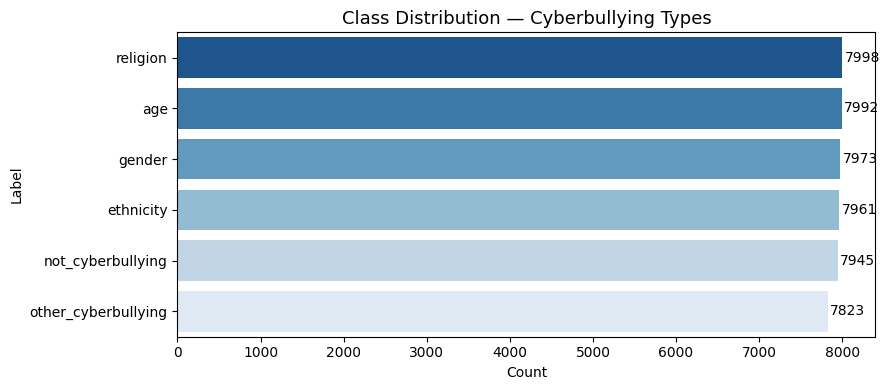

In [5]:
# ── Class distribution ─────────────────────────────────────────────────────
label_counts = df['cyberbullying_type'].value_counts()
print("Class distribution:")
print(label_counts)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='Blues_r', ax=ax)
ax.set_title('Class Distribution — Cyberbullying Types', fontsize=13)
ax.set_xlabel('Count')
ax.set_ylabel('Label')
for i, v in enumerate(label_counts.values):
    ax.text(v + 30, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

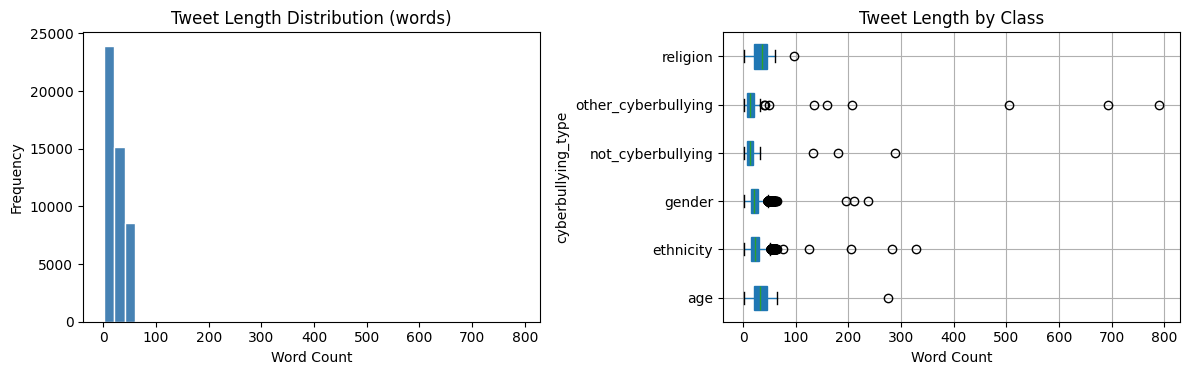

count    47692.000000
mean        23.704835
std         15.434881
min          1.000000
25%         13.000000
50%         20.000000
75%         32.000000
max        790.000000
Name: tweet_len, dtype: float64


In [6]:
# ── Tweet length distribution ──────────────────────────────────────────────
df['tweet_len'] = df['tweet_text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['tweet_len'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Tweet Length Distribution (words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

df.boxplot(column='tweet_len', by='cyberbullying_type', ax=axes[1],
           vert=False, patch_artist=True)
axes[1].set_title('Tweet Length by Class')
axes[1].set_xlabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df['tweet_len'].describe())

---
## Section 2 — Preprocessing & Train/Val/Test Split

In [7]:
def clean_tweet(text: str) -> str:
    """Basic tweet cleaning — remove URLs, mentions, extra whitespace."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#', '', text)                     # keep hashtag words, remove #
    text = re.sub(r'[^\w\s!?.,]', ' ', text)          # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text.lower()

df = df.dropna(subset=['tweet_text', 'cyberbullying_type'])
df['tweet_clean'] = df['tweet_text'].apply(clean_tweet)

# Remove empty rows after cleaning
df = df[df['tweet_clean'].str.len() > 3].reset_index(drop=True)
print(f"Rows after cleaning: {len(df)}")
df[['tweet_text', 'tweet_clean', 'cyberbullying_type']].head(3)

Rows after cleaning: 47307


,tweet_text,tweet_clean,cyberbullying_type
0,"In other words #katandandre, your food was cra...","in other words katandandre, your food was crap...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white? mkr theblock imacele...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore? or more red velvet cupcakes?,not_cyberbullying


In [8]:
# ── Label encoding ─────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['cyberbullying_type'])

num_labels = len(label_encoder.classes_)
id2label   = {i: l for i, l in enumerate(label_encoder.classes_)}
label2id   = {l: i for i, l in id2label.items()}

print(f"Number of classes: {num_labels}")
print(f"Label mapping: {id2label}")

# ── Train / Val / Test split  70 / 15 / 15 ────────────────────────────────
X = df['tweet_clean'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

Number of classes: 6
Label mapping: {0: 'age', 1: 'ethnicity', 2: 'gender', 3: 'not_cyberbullying', 4: 'other_cyberbullying', 5: 'religion'}

Train : 33114
Val   : 7096
Test  : 7097


---
## Section 3 — Baseline: TF-IDF + Classical ML

The baseline uses **TF-IDF** (Term Frequency–Inverse Document Frequency) to convert raw text into sparse numerical vectors, then trains classical ML classifiers on top.

- **TF-IDF**: captures word importance across documents, but no semantic understanding
- **Logistic Regression**: fast, interpretable, good regularisation
- **Linear SVM**: strong baseline for high-dimensional sparse text features

In [9]:
# ── TF-IDF Vectorizer ─────────────────────────────────────────────────────
# unigrams + bigrams, top 50k features, log-normalized TF
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (33114, 50000)


In [27]:
import pandas as pd

# Convert a small slice to dense DataFrame to see it
sample_dense = X_train_tfidf[:5].toarray()  # first 5 tweets
feature_names = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(sample_dense, columns=feature_names)

# Most columns are 0 — show only non-zero columns for these 5 tweets
df_tfidf_nonzero = df_tfidf.loc[:, (df_tfidf != 0).any(axis=0)]
print(f"Shape (full)    : {X_train_tfidf.shape}")       # (n_tweets, 50000)
print(f"Non-zero cols   : {df_tfidf_nonzero.shape[1]}")
df_tfidf_nonzero.head()

Shape (full)    : (33114, 50000)
Non-zero cols   : 161


,ability,ability to,about,about people,accept,account,am,am going,americans,and,...,who,why,why these,will,will follow,witch,with,with racist,you,you are
0,0.231027,0.243667,0.096286,0.247037,0.000000,0.000000,0.000000,0.000000,0.00000,0.060604,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.148683,0.000000,0.000000,0.000000,0.00000,0.045067,...,0.000000,0.087307,0.213198,0.000000,0.000000,0.191677,0.000000,0.000000,0.048100,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.178495,0.000000,0.000000,0.18227,0.056677,...,0.086439,0.000000,0.000000,0.110234,0.257273,0.000000,0.086925,0.249576,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.150571,0.309592,0.00000,0.065444,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.069848,0.143534
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
# ── Baseline 1: Logistic Regression ───────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
lr_f1     = f1_score(y_test, y_pred_lr, average='macro')

print("[Baseline 1] Logistic Regression — Test Set")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))
print(f"Macro F1: {lr_f1:.4f}")

[Baseline 1] Logistic Regression — Test Set
                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1199
          ethnicity       0.98      0.98      0.98      1194
             gender       0.91      0.81      0.86      1192
  not_cyberbullying       0.60      0.55      0.57      1174
other_cyberbullying       0.59      0.66      0.62      1138
           religion       0.93      0.96      0.95      1200

           accuracy                           0.83      7097
          macro avg       0.83      0.82      0.82      7097
       weighted avg       0.83      0.83      0.83      7097

Macro F1: 0.8249


In [11]:
# ── Baseline 2: Linear SVM ────────────────────────────────────────────────
svm = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
svm_f1     = f1_score(y_test, y_pred_svm, average='macro')

print("[Baseline 2] Linear SVM — Test Set")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))
print(f"Macro F1: {svm_f1:.4f}")

[Baseline 2] Linear SVM — Test Set
                     precision    recall  f1-score   support

                age       0.96      0.99      0.97      1199
          ethnicity       0.97      0.98      0.98      1194
             gender       0.88      0.85      0.86      1192
  not_cyberbullying       0.58      0.53      0.55      1174
other_cyberbullying       0.56      0.60      0.58      1138
           religion       0.95      0.96      0.96      1200

           accuracy                           0.82      7097
          macro avg       0.82      0.82      0.82      7097
       weighted avg       0.82      0.82      0.82      7097

Macro F1: 0.8165


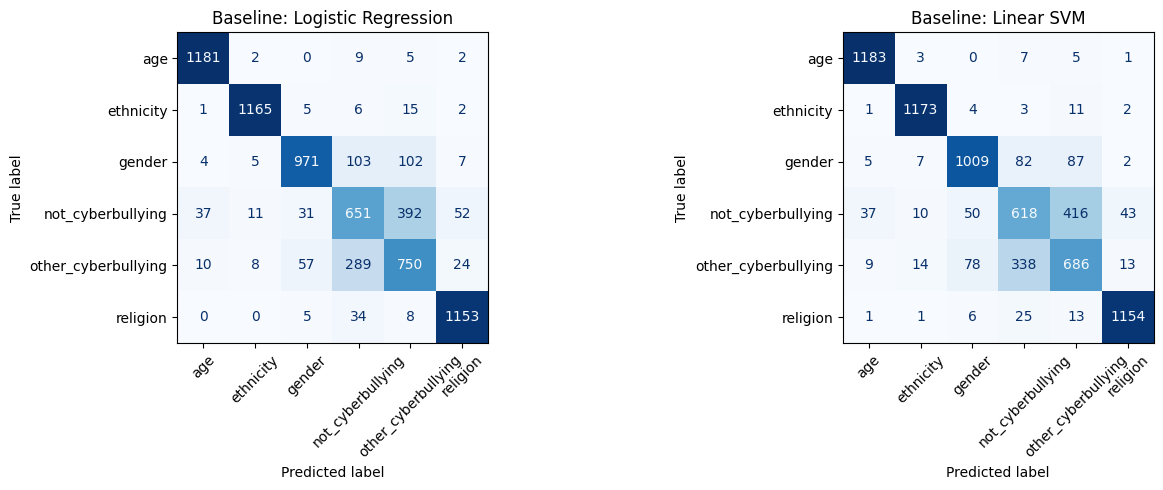

In [12]:
# ── Confusion matrices for both baselines ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_svm],
    ['Logistic Regression', 'Linear SVM']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Baseline: {title}')

plt.tight_layout()
plt.show()

---
## Section 4 — Main Model: Fine-Tuned DistilBERT

**DistilBERT** is an encoder-based transformer — a distilled (lighter) version of BERT that retains ~97% of BERT's performance at 40% fewer parameters.

Architecture:
```
Tweet Text
    │
    ▼
Tokenizer  →  [CLS] token + subword tokens + [SEP]
    │
    ▼
DistilBERT encoder  →  contextual embeddings
    │
    ▼
[CLS] vector  →  Linear classification head
    │
    ▼
Softmax → 6-class prediction
```

In [13]:
# ── Tokenizer ─────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Quick sanity check — see how a tweet gets tokenized
sample = X_train[0]
tokens = tokenizer(sample, truncation=True, max_length=MAX_LEN)
print(f"Sample tweet  : {sample[:80]}...")
print(f"Token IDs     : {tokens['input_ids'][:10]} ...")
print(f"Token count   : {len(tokens['input_ids'])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample tweet  : i m usually optimistic about people and their ability to change. but i ve heard ...
Token IDs     : [101, 1045, 1049, 2788, 21931, 2055, 2111, 1998, 2037, 3754] ...
Token count   : 25


In [14]:
# ── PyTorch Dataset wrapper ────────────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=MAX_LEN,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TweetDataset(X_train, y_train)
val_dataset   = TweetDataset(X_val,   y_val)
test_dataset  = TweetDataset(X_test,  y_test)

print(f"Train dataset size : {len(train_dataset)}")
print(f"Val dataset size   : {len(val_dataset)}")
print(f"Test dataset size  : {len(test_dataset)}")

Train dataset size : 33114
Val dataset size   : 7096
Test dataset size  : 7097


In [15]:
# ── Load pre-trained DistilBERT with classification head ──────────────────
# AutoModelForSequenceClassification automatically adds a Linear layer
# on top of the [CLS] token output — no manual architecture needed
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 66,958,086
Trainable parameters: 66,958,086


In [16]:
# ── Evaluation metrics function ────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds     = np.argmax(logits, axis=-1)
    macro_f1  = f1_score(labels, preds, average='macro')
    accuracy  = (preds == labels).mean()
    return {'macro_f1': macro_f1, 'accuracy': accuracy}

In [18]:
# ── Training Arguments ────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,               # warmup for first 10% of steps
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=100,
    fp16=torch.cuda.is_available(),  # mixed precision on GPU
    seed=SEED,
    report_to='none',                # disable wandb
)

print("Training arguments configured.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured.


In [19]:
# ── Trainer & Training ────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.818639,0.816721,0.831300,0.838923
2,0.690630,0.700774,0.860478,0.862599
3,0.576916,0.712103,0.855113,0.859780
4,0.505521,0.732640,0.853043,0.856962


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2072, training_loss=0.8124373557484749, metrics={'train_runtime': 904.1259, 'train_samples_per_second': 146.502, 'train_steps_per_second': 2.292, 'total_flos': 4386838348910592.0, 'train_loss': 0.8124373557484749, 'epoch': 4.0})

In [20]:
# ── Save fine-tuned model to Drive ────────────────────────────────────────
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Model saved to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./distilbert-cyberbullying


---
## Section 5 — Evaluation & Comparison

In [21]:
# ── DistilBERT test set evaluation ────────────────────────────────────────
preds_output = trainer.predict(test_dataset)
y_pred_bert  = np.argmax(preds_output.predictions, axis=-1)
bert_f1      = f1_score(y_test, y_pred_bert, average='macro')

print("[Main Model] DistilBERT (fine-tuned) — Test Set")
print(classification_report(y_test, y_pred_bert, target_names=label_encoder.classes_))
print(f"Macro F1: {bert_f1:.4f}")

[Main Model] DistilBERT (fine-tuned) — Test Set
                     precision    recall  f1-score   support

                age       0.99      0.98      0.98      1199
          ethnicity       0.98      0.98      0.98      1194
             gender       0.89      0.85      0.87      1192
  not_cyberbullying       0.68      0.59      0.64      1174
other_cyberbullying       0.64      0.75      0.69      1138
           religion       0.95      0.97      0.96      1200

           accuracy                           0.86      7097
          macro avg       0.86      0.85      0.85      7097
       weighted avg       0.86      0.86      0.86      7097

Macro F1: 0.8533


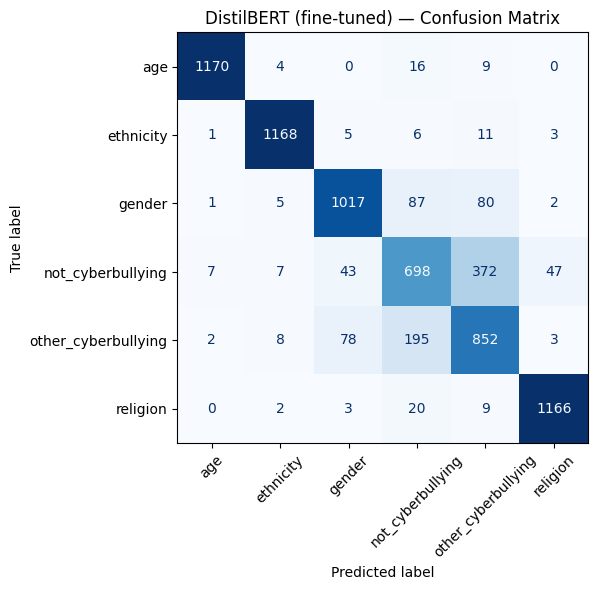

In [22]:
# ── DistilBERT confusion matrix ────────────────────────────────────────────
cm_bert = confusion_matrix(y_test, y_pred_bert)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_bert, display_labels=label_encoder.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
ax.set_title('DistilBERT (fine-tuned) — Confusion Matrix')
plt.tight_layout()
plt.show()

In [23]:
# ── Summary comparison table ──────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'    : ['TF-IDF + Logistic Regression', 'TF-IDF + Linear SVM', 'DistilBERT (fine-tuned)'],
    'Features' : ['Sparse TF-IDF vectors', 'Sparse TF-IDF vectors', 'Contextual embeddings [CLS]'],
    'Macro F1' : [round(lr_f1, 4), round(svm_f1, 4), round(bert_f1, 4)],
})

print("="*60)
print("RESULTS SUMMARY")
print("="*60)
print(summary.to_string(index=False))

RESULTS SUMMARY
                       Model                    Features  Macro F1
TF-IDF + Logistic Regression       Sparse TF-IDF vectors    0.8249
         TF-IDF + Linear SVM       Sparse TF-IDF vectors    0.8165
     DistilBERT (fine-tuned) Contextual embeddings [CLS]    0.8533


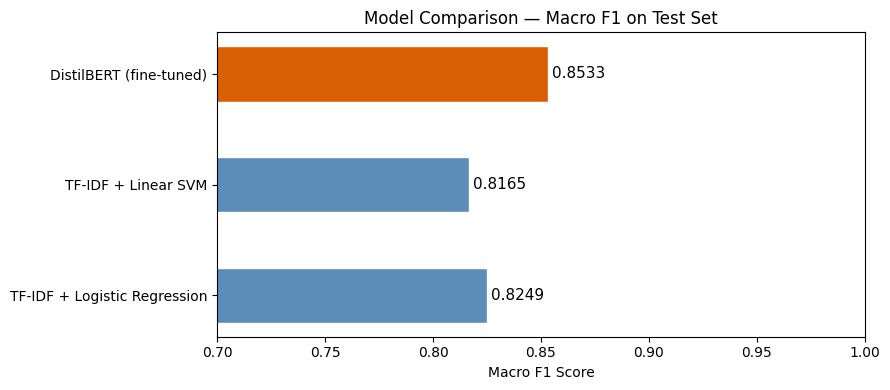

In [24]:
# ── Bar chart comparison ──────────────────────────────────────────────────
models  = summary['Model'].tolist()
f1_vals = summary['Macro F1'].tolist()
colors  = ['#5b8db8', '#5b8db8', '#d95f02']  # highlight DistilBERT

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(models, f1_vals, color=colors, edgecolor='white', height=0.5)
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('Macro F1 Score')
ax.set_title('Model Comparison — Macro F1 on Test Set')
for bar, val in zip(bars, f1_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## Conclusion

### What was built

| Step | Component | Detail |
|------|-----------|--------|
| 1 | **EDA** | Class distribution, tweet length analysis |
| 2 | **Preprocessing** | URL/mention removal, lowercasing, 70/15/15 stratified split |
| 3 | **Baseline** | TF-IDF (unigrams+bigrams) + Logistic Regression & Linear SVM |
| 4 | **Main Model** | DistilBERT fine-tuned with HuggingFace `Trainer` API |
| 5 | **Evaluation** | Per-class classification report + Macro F1 + confusion matrices |

### Why encoder over decoder?

For classification tasks, **encoder-based models** (BERT, DistilBERT, RoBERTa) are preferred because they produce a rich **[CLS] token embedding** that captures the full sentence meaning — ideal for mapping to a label. Decoder-based models (GPT, LLaMA) are designed for text generation, not classification.

### Why DistilBERT over BERT?

DistilBERT has 40% fewer parameters than BERT, trains 60% faster, but retains ~97% of performance — a practical tradeoff for a student project on Colab hardware.

### Next steps

- Try `roberta-base` — generally stronger on social media/hate speech text
- Add cross-validation for more robust evaluation
- Experiment with longer `MAX_LEN` (256) to capture more context
- Error analysis — inspect misclassified examples per class